In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
Index(['CustomerID', 'Genre', 'Age', 'Annual Income

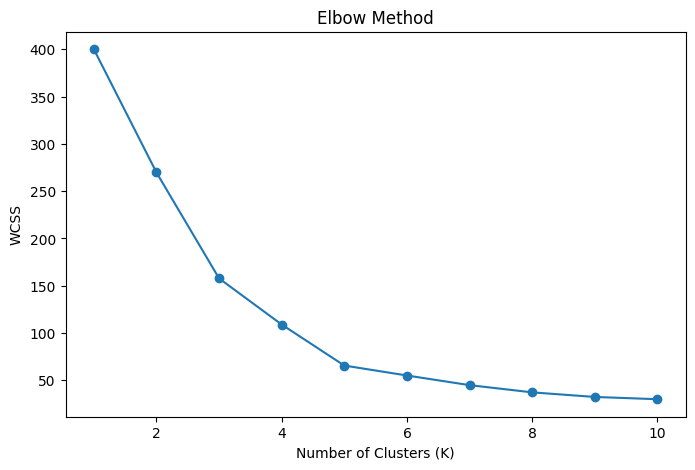

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


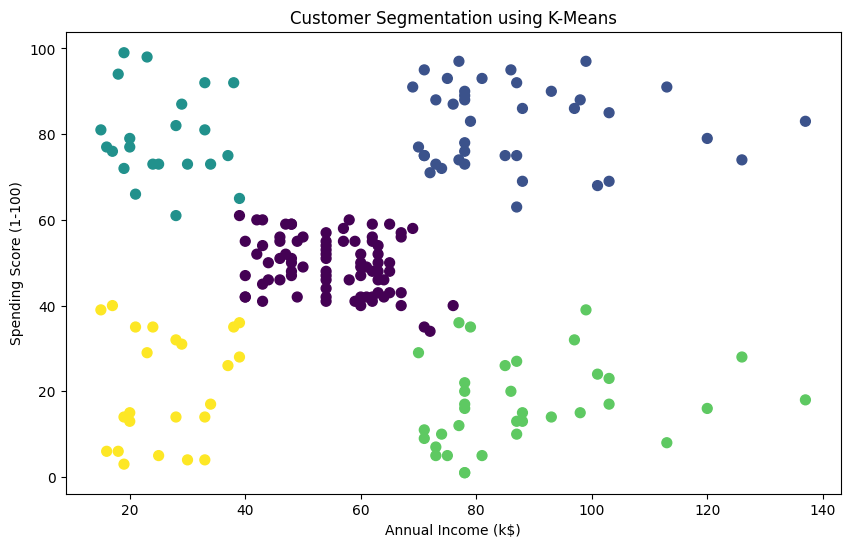

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler




df = pd.read_csv("/content/drive/MyDrive/BML_Semester5_Diploma/BML/archive/Mall_Customers.csv")


# 3. Examine the dataset

print(df.head())
print(df.info())
print(df.columns)


# 4. Select Annual Income and Spending Score

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]


# 5. Scale the selected features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 6. Elbow Method

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


# Plot Elbow graph

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


# 7. Create K-Means model

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)


# 8. Fit the model

kmeans.fit(X_scaled)


# 9. Assign each customer to a cluster

df["Cluster"] = kmeans.labels_


# Display cluster assignments

print(df.head())


# 10. Visualize clusters

plt.figure(figsize=(10, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    s=50
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()


# 11. Interpret clusters

cluster_summary = df.groupby("Cluster")[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print(cluster_summary)